# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_curve, roc_auc_score, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy.stats import chi2_contingency, f_oneway, mannwhitneyu
from google.colab import files

import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [2]:
df = pd.read_csv("Hotel Reservations.csv")
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

# Pre-processing + EDA

## Data Cleaning

### Missing Value

In [ ]:
df.isnull().sum().sum()

np.int64(0)

### Duplikasi Data

In [ ]:
df.duplicated().sum()

np.int64(0)

### Outlier

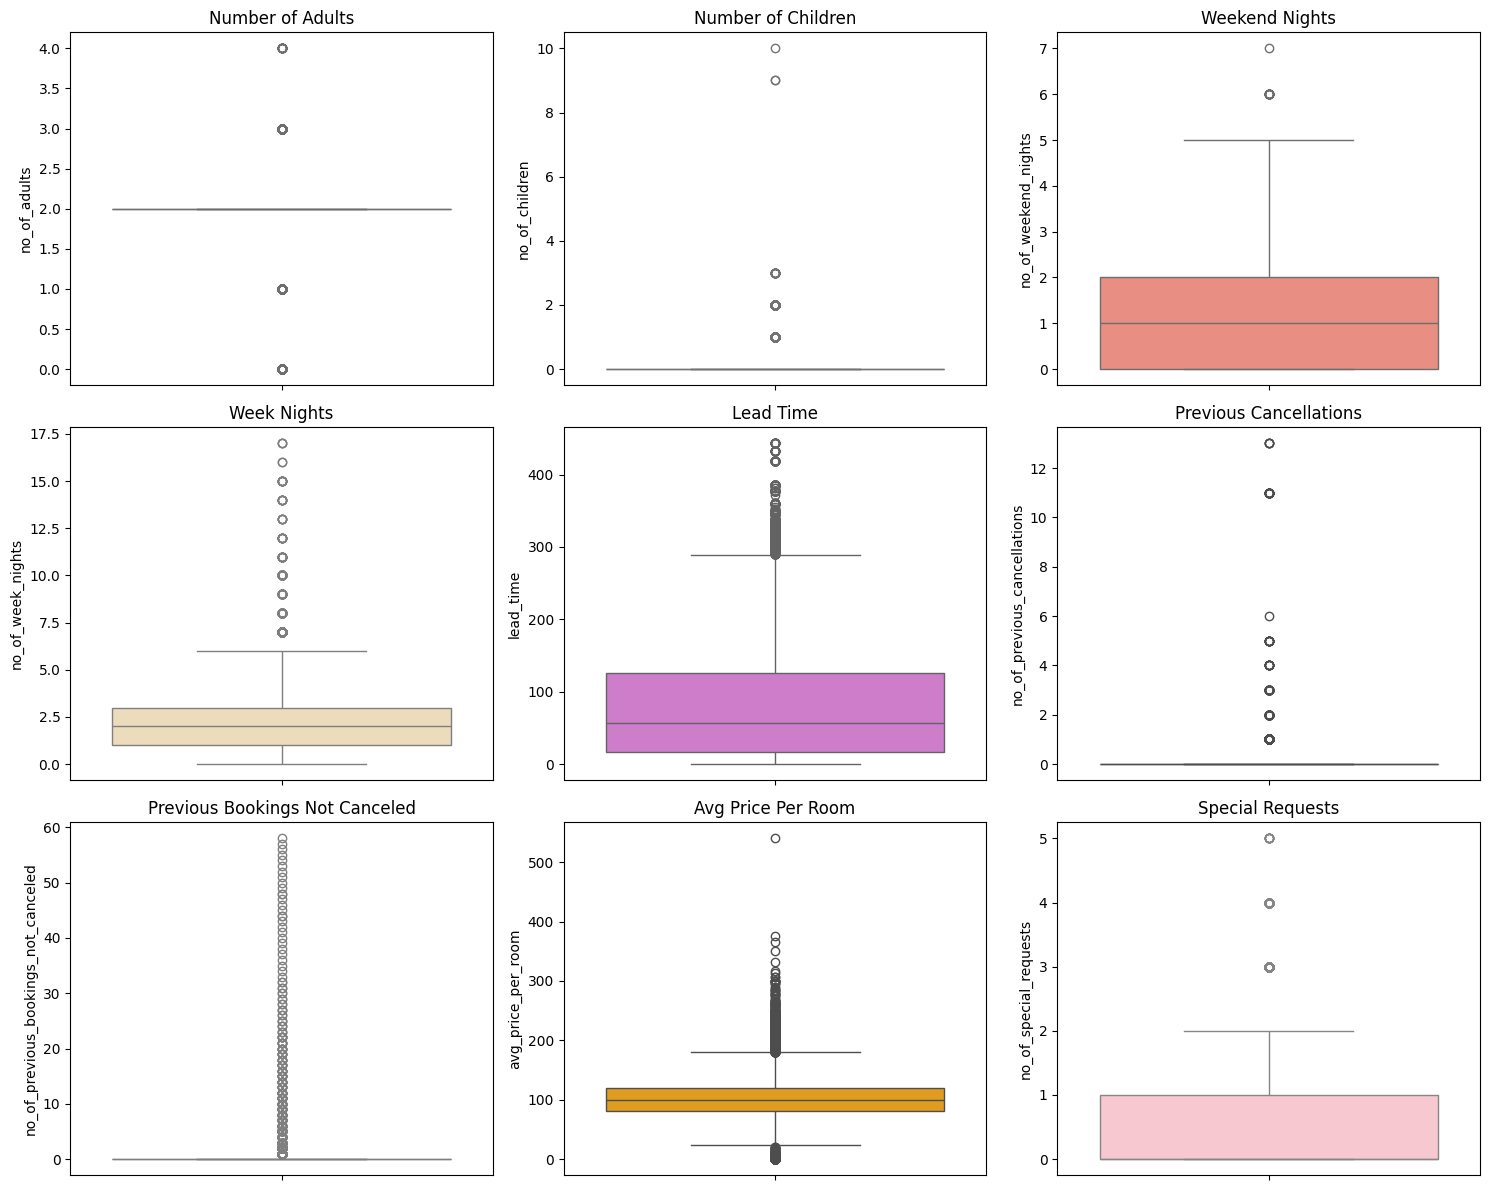

In [ ]:
# Mengatur ukuran canvas (Figure)
fig, ax = plt.subplots(3, 3, figsize=(15, 12))

# Baris 1
sns.boxplot(y=df['no_of_adults'], ax=ax[0, 0], color='skyblue').set_title('Number of Adults')
sns.boxplot(y=df['no_of_children'], ax=ax[0, 1], color='lightgreen').set_title('Number of Children')
sns.boxplot(y=df['no_of_weekend_nights'], ax=ax[0, 2], color='salmon').set_title('Weekend Nights')

# Baris 2
sns.boxplot(y=df['no_of_week_nights'], ax=ax[1, 0], color='wheat').set_title('Week Nights')
sns.boxplot(y=df['lead_time'], ax=ax[1, 1], color='orchid').set_title('Lead Time')
sns.boxplot(y=df['no_of_previous_cancellations'], ax=ax[1, 2], color='cyan').set_title('Previous Cancellations')

# Baris 3
sns.boxplot(y=df['no_of_previous_bookings_not_canceled'], ax=ax[2, 0], color='lightgrey').set_title('Previous Bookings Not Canceled')
sns.boxplot(y=df['avg_price_per_room'], ax=ax[2, 1], color='orange').set_title('Avg Price Per Room')
sns.boxplot(y=df['no_of_special_requests'], ax=ax[2, 2], color='pink').set_title('Special Requests')

# Mengatur tata letak agar rapi
plt.tight_layout()
plt.show()

## Korelasi

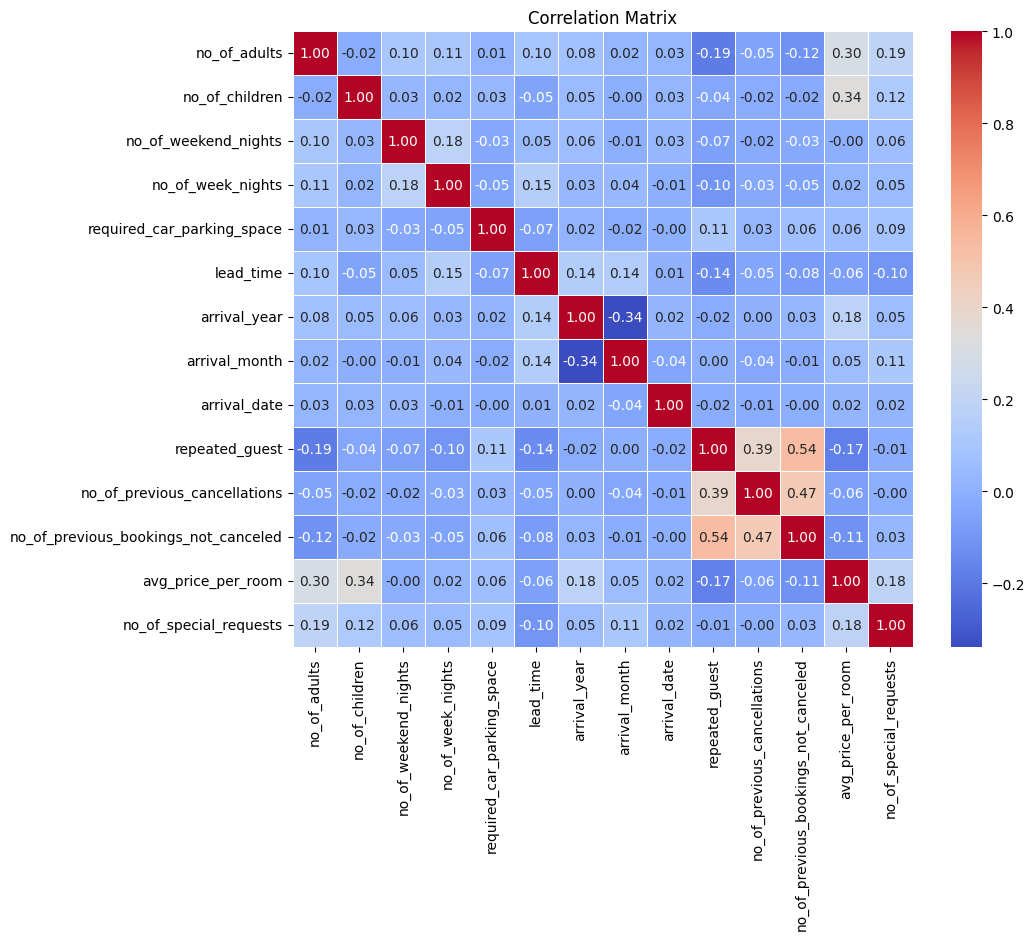

In [ ]:
numeric_columns=df.select_dtypes(include=['float64','int64'])
correlation_matrix=numeric_columns.corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

## Multikolinearitas

In [ ]:
X = add_constant(numeric_columns)
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif

,Variable,VIF
0,const,3.499023e+07
1,no_of_adults,1.205084e+00
2,no_of_children,1.164000e+00
3,no_of_weekend_nights,1.051932e+00
4,no_of_week_nights,1.069202e+00
5,required_car_parking_space,1.029839e+00
6,lead_time,1.159714e+00
7,arrival_year,1.266079e+00
8,arrival_month,1.239673e+00
9,arrival_date,1.004813e+00


## Distribusi Target

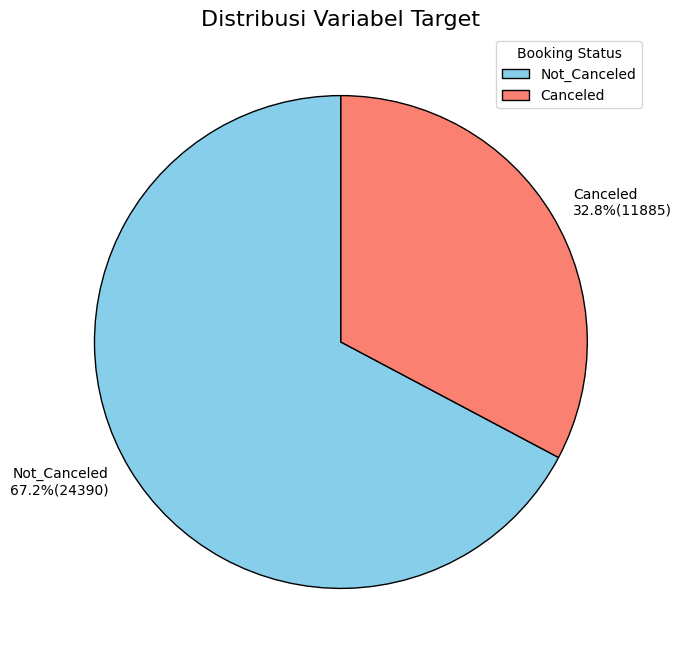

In [3]:
# Menghitung distribusi variabel target 'Churn'
target_counts = df['booking_status'].value_counts()
total = target_counts.sum()

# Membuat label dengan format Persentase dan Jumlah
labels = [f'{index}\n{count / total:.1%}({count})'
          for index, count in target_counts.items()]

# Pengaturan Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(
    target_counts,
    labels=labels,
    autopct='',
    startangle=90,
    colors=['skyblue', 'salmon'],
    wedgeprops={'edgecolor': 'black'}
)

# Menambahkan legenda terpisah untuk kejelasan
plt.legend(target_counts.index, title="Booking Status", loc="best")

plt.title('Distribusi Variabel Target', fontsize=16)
plt.show()

## Summary Statistics

### Kategorik

In [ ]:
kategori_counts = {}
for col in df.select_dtypes(include=['object', 'category']).columns:
    kategori_counts[col] = df[col].value_counts()

for col, counts in kategori_counts.items():
    print(counts)

Booking_ID
INN36275    1
INN00001    1
INN00002    1
INN00003    1
INN00004    1
           ..
INN00023    1
INN00024    1
INN00025    1
INN00026    1
INN00027    1
Name: count, Length: 36275, dtype: int64
type_of_meal_plan
Meal Plan 1     27835
Not Selected     5130
Meal Plan 2      3305
Meal Plan 3         5
Name: count, dtype: int64
room_type_reserved
Room_Type 1    28130
Room_Type 4     6057
Room_Type 6      966
Room_Type 2      692
Room_Type 5      265
Room_Type 7      158
Room_Type 3        7
Name: count, dtype: int64
market_segment_type
Online           23214
Offline          10528
Corporate         2017
Complementary      391
Aviation           125
Name: count, dtype: int64
booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64


### Numerik

In [ ]:
df.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.844962,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,103.423539,0.619655
std,0.518715,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,35.089424,0.786236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


## Feature Engineering

In [ ]:
df['required_car_parking_space'] = df['required_car_parking_space'].map({0: 'No', 1: 'Yes'})
df['repeated_guest'] = df['repeated_guest'].map({0: 'No', 1: 'Yes'})

## Feature Extraction

In [ ]:
# Ubah month = 2, year = 2018, dan arrival_date > 28 → jadi 28
mask = (df['arrival_year'] == 2018) & (df['arrival_month'] == 2) & (df['arrival_date'] > 28)
df.loc[mask, 'arrival_date'] = 28

In [ ]:
df['arrival_datetime'] = pd.to_datetime(
    dict(
        year=df['arrival_year'],
        month=df['arrival_month'],
        day=df['arrival_date']
    ),
    errors='coerce'
)

In [ ]:
# hitung reservation_date dengan mengurangi lead_time (hari)
df['reservation_datetime'] = (
    df['arrival_datetime'] - pd.to_timedelta(df['lead_time'].astype(int), unit='D')
).dt.floor('D')

# (opsional) ubah format tampilan reservation_date jadi yyyy-mm-dd (date-only)
df['reservation_datetime'] = pd.to_datetime(
    df['arrival_datetime'] - pd.to_timedelta(df['lead_time'], unit='D')
).dt.normalize()

In [ ]:
df['total_nights'] = df['no_of_weekend_nights'] + df['no_of_week_nights']
df['total_people'] = df['no_of_adults'] + df['no_of_children']

df['have_children'] = np.where(df['no_of_children'] > 0, 'Yes', 'No')
df['single'] = np.where(df['total_people'] == 1, 'Yes', 'No')

df['lead_time_group'] = pd.cut(
    df['lead_time'],
    bins=[-1, 2, 7, 30, 90, 180, 9999],
    labels=[
        '0–2 days',
        '3–7 days',
        '8–30 days',
        '31–90 days',
        '91–180 days',
        '>180 days'
    ]
)
df['lead_time_group'] = df['lead_time_group'].astype('object')

# Cek Hasil
print(df[['total_nights', 'total_people','have_children', 'single', 'lead_time_group']].head())

   total_nights  total_people have_children single lead_time_group
0             3             2            No     No       >180 days
1             5             2            No     No        3–7 days
2             3             1            No    Yes        0–2 days
3             2             2            No     No       >180 days
4             2             2            No     No      31–90 days


Menyimpan CSV Lengkap

In [ ]:
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,...,avg_price_per_room,no_of_special_requests,booking_status,arrival_datetime,reservation_datetime,total_nights,total_people,have_children,single,lead_time_group
0,INN00001,2,0,1,2,Meal Plan 1,No,Room_Type 1,224,2017,...,65.00,0,Not_Canceled,2017-10-02,2017-02-20,3,2,No,No,>180 days
1,INN00002,2,0,2,3,Not Selected,No,Room_Type 1,5,2018,...,106.68,1,Not_Canceled,2018-11-06,2018-11-01,5,2,No,No,3–7 days
2,INN00003,1,0,2,1,Meal Plan 1,No,Room_Type 1,1,2018,...,60.00,0,Canceled,2018-02-28,2018-02-27,3,1,No,Yes,0–2 days
3,INN00004,2,0,0,2,Meal Plan 1,No,Room_Type 1,211,2018,...,100.00,0,Canceled,2018-05-20,2017-10-21,2,2,No,No,>180 days
4,INN00005,2,0,1,1,Not Selected,No,Room_Type 1,48,2018,...,94.50,0,Canceled,2018-04-11,2018-02-22,2,2,No,No,31–90 days


In [ ]:
df.to_csv('data_hotel_clean.csv', index=False)
files.download('data_hotel_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_clean = df.drop(['Booking_ID', 'arrival_month', 'arrival_year', 'arrival_date',
                    'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights',
                    'lead_time', 'arrival_datetime', 'reservation_datetime'], axis=1)

In [ ]:
df_clean.head()

,type_of_meal_plan,required_car_parking_space,room_type_reserved,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_nights,total_people,have_children,single,lead_time_group
0,Meal Plan 1,No,Room_Type 1,Offline,No,0,0,65.00,0,Not_Canceled,3,2,No,No,>180 days
1,Not Selected,No,Room_Type 1,Online,No,0,0,106.68,1,Not_Canceled,5,2,No,No,3–7 days
2,Meal Plan 1,No,Room_Type 1,Online,No,0,0,60.00,0,Canceled,3,1,No,Yes,0–2 days
3,Meal Plan 1,No,Room_Type 1,Online,No,0,0,100.00,0,Canceled,2,2,No,No,>180 days
4,Not Selected,No,Room_Type 1,Online,No,0,0,94.50,0,Canceled,2,2,No,No,31–90 days


## Feature Selection

In [ ]:
# Target variable
target = 'booking_status'

# Pisahkan kolom
categorical_features = [col for col in df_clean.columns if df_clean[col].dtype == 'object' and col != target]
numeric_features = [col for col in df_clean.columns if df_clean[col].dtype != 'object' and col != target]

### ANOVA F-Test (Numerical Features)

In [ ]:
# ======================
# ANOVA F-Test (Numerik)
# ======================
print("\n=== ANOVA F-Test (Numerical Features) ===")
for col in numeric_features:
    groups = [df_clean[df_clean[target]==val][col] for val in df_clean[target].unique()]
    f_stat, p = f_oneway(*groups)
    print(f"{col}: p-value = {p:.4f}")


=== ANOVA F-Test (Numerical Features) ===
no_of_previous_cancellations: p-value = 0.0000
no_of_previous_bookings_not_canceled: p-value = 0.0000
avg_price_per_room: p-value = 0.0000
no_of_special_requests: p-value = 0.0000
total_nights: p-value = 0.0000
total_people: p-value = 0.0000


### Chi-Square Test (Categorical Features)

In [ ]:
# ======================
# Uji Chi-Square (Kategorik)
# ======================
print("=== Chi-Square Test (Categorical Features) ===")
for col in categorical_features:
    table = pd.crosstab(df_clean[col], df_clean[target])
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"{col}: p-value = {p:.4f}")

=== Chi-Square Test (Categorical Features) ===
type_of_meal_plan: p-value = 0.0000
required_car_parking_space: p-value = 0.0000
room_type_reserved: p-value = 0.0000
market_segment_type: p-value = 0.0000
repeated_guest: p-value = 0.0000
have_children: p-value = 0.0000
single: p-value = 0.0000
lead_time_group: p-value = 0.0000


## Encoding Variabel

In [ ]:
# Encoding variabel target (Yes=1, No=0)
df_clean['booking_status'] = df_clean['booking_status'].map({'Canceled': 1, 'Not_Canceled': 0})

# Split Data
X = df_clean.drop('booking_status', axis=1)
y = df_clean['booking_status']

# Encoding variabel kategorik
xcat = X.select_dtypes(include=["object"])
ohe = OneHotEncoder(sparse_output=False, drop="first")

x_ohe = pd.DataFrame(ohe.fit_transform(xcat), columns=ohe.get_feature_names_out(xcat.columns))
x_encode = pd.concat([X.drop(columns=xcat.columns).reset_index(drop=True),
               x_ohe.reset_index(drop=True)], axis=1)

with open('encoder_hotel.pkl', 'wb') as file:
    pickle.dump(ohe, file)
files.download('encoder_hotel.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Data Modelling

## Initialize models

In [ ]:
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Naive Bayes': GaussianNB()
}

## Paramater Tuning

In [ ]:
param_grids = {
    'Random Forest': {
        'n_estimators': [50, 100],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    },
    'Logistic Regression': {
        'C': [0.1, 1, 10],
        'solver': ['liblinear', 'lbfgs']
    },
    'Naive Bayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7]
    }
}

## Repeated Holdout (n=10)

Processing: Random Forest...
Processing: Logistic Regression...
Processing: Naive Bayes...

Model Performance Table:


,Model,Accuracy,Sensitivity,Specificity,AUC,Train Accuracy,Test Accuracy,Overfitting Gap
0,Random Forest,0.850476,0.797939,0.876265,0.917894,0.941054,0.850476,0.090578
1,Logistic Regression,0.784810,0.790755,0.781930,0.863251,0.784620,0.784810,-0.000190
2,Naive Bayes,0.420689,0.964677,0.157591,0.773805,0.562344,0.420689,0.141655


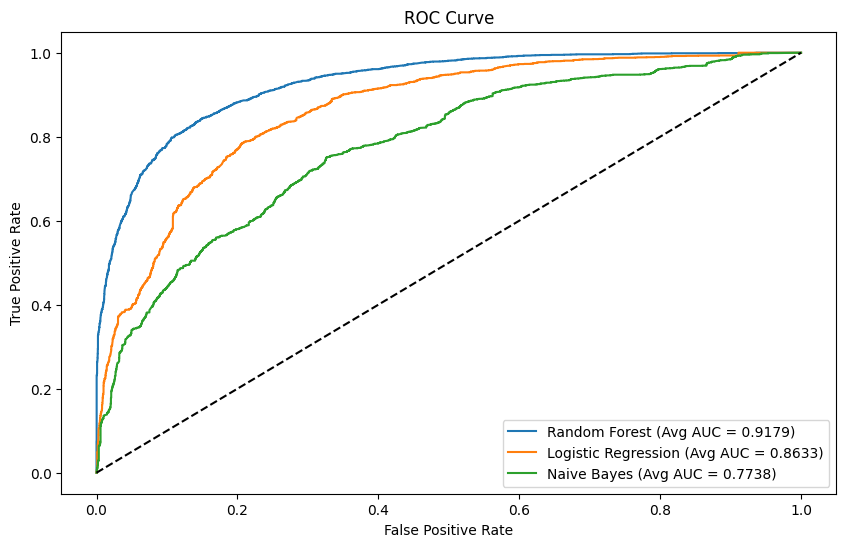

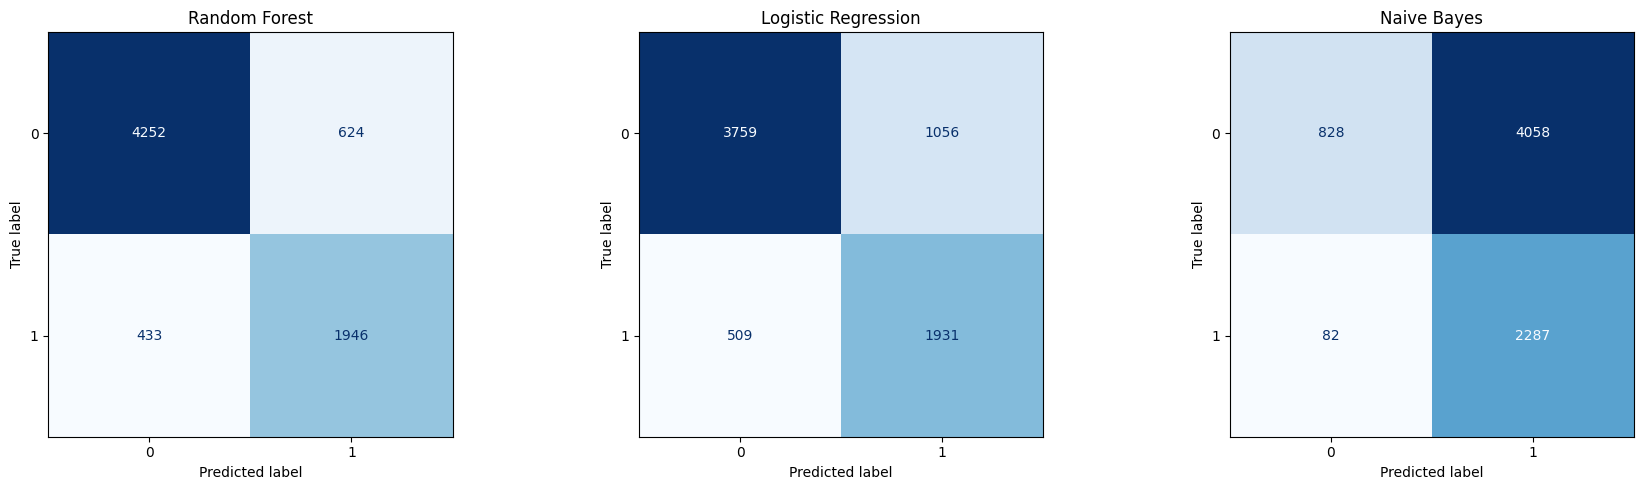

In [ ]:
# Store results
results = {}
roc_curves = {}
final_plot_data = {}

# Perform repeat holdout cross-validation
n_repeats = 10

for model_name, base_model in models.items():
    accuracies = []
    sensitivities = []
    specificities = []
    aucs = []
    train_accuracies = []
    test_accuracies = []

    print(f"Processing: {model_name}...")

    for i in range(n_repeats):
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(x_encode, y, test_size=0.2, random_state=None)

        # Scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        #SMOTE
        smote = SMOTE(random_state=42)
        X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

        # GRID SEARCH TUNING
        if model_name in param_grids:
            grid_search = GridSearchCV(
                estimator=base_model,
                param_grid=param_grids[model_name],
                cv=5,
                scoring='accuracy',
                n_jobs=-1
            )
            grid_search.fit(X_train_smote, y_train_smote)
            model = grid_search.best_estimator_

        else:
            # Jika tidak ada di grid, pakai model default
            model = base_model
            model.fit(X_train_smote, y_train_smote)

        # Predict on training and test sets
        y_train_pred = model.predict(X_train_smote)
        y_test_pred = model.predict(X_test_scaled)

        # Predict probabilities for AUC if available
        y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None

        # Metrics calculation
        accuracy = accuracy_score(y_test, y_test_pred)
        sensitivity = recall_score(y_test, y_test_pred)
        tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        auc_score = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

        # Train/Test accuracy
        train_accuracy = accuracy_score(y_train_smote, y_train_pred)
        test_accuracy = accuracy_score(y_test, y_test_pred)

        # Store fold results
        accuracies.append(accuracy)
        sensitivities.append(sensitivity)
        specificities.append(specificity)
        aucs.append(auc_score)
        train_accuracies.append(train_accuracy)
        test_accuracies.append(test_accuracy)

        # Simpan data iterasi akhir
        if i == n_repeats - 1:
            final_plot_data[model_name] = {
                'y_test': y_test,
                'y_pred': y_test_pred,
                'y_proba': y_proba
            }

    # Aggregate metrics
    results[model_name] = {
        'Accuracy': np.mean(accuracies),
        'Sensitivity (Recall)': np.mean(sensitivities),
        'Specificity': np.mean(specificities),
        'AUC': np.mean(aucs),
        'Train Accuracy': np.mean(train_accuracies),
        'Test Accuracy': np.mean(test_accuracies),
        'Overfitting Gap': np.mean(train_accuracies) - np.mean(test_accuracies)
    }

    # Store ROC curve for the last iteration
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_curves[model_name] = (fpr, tpr, np.mean(aucs))

# Create DataFrame for the results
metrics_df = pd.DataFrame.from_dict(results, orient='index').reset_index()
metrics_df.columns = [
    "Model", "Accuracy", "Sensitivity", "Specificity", "AUC",
    "Train Accuracy", "Test Accuracy", "Overfitting Gap"
]

# Apply styling to highlight max values in the table
styled_metrics_df = metrics_df.style.highlight_max(
    subset=['Accuracy', 'Sensitivity', 'Specificity', 'AUC', 'Train Accuracy', 'Test Accuracy'],
    color='lightgreen'
)

# Display the styled table
print("\nModel Performance Table:")
display(styled_metrics_df)

# 1. Plot ROC Curves
plt.figure(figsize=(10, 6))
for model_name, (fpr, tpr, auc_score) in roc_curves.items():
    plt.plot(fpr, tpr, label=f'{model_name} (Avg AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 2. Plot Confusion Matrices
fig, axes = plt.subplots(1, len(models), figsize=(18, 5))

for ax, (model_name, data) in zip(axes, final_plot_data.items()):
    ConfusionMatrixDisplay.from_predictions(
        data['y_test'],
        data['y_pred'],
        ax=ax,
        cmap='Blues',
        colorbar=False
    )
    ax.set_title(f"{model_name}")

plt.tight_layout()
plt.show()

## K-Fold CV (K=10)

Processing: Random Forest...
Processing: Logistic Regression...
Processing: Naive Bayes...

Model Performance Table:


,Model,Accuracy,Sensitivity,Specificity,AUC,Train Accuracy,Test Accuracy,Overfitting Gap
0,Random Forest,0.852625,0.804232,0.876160,0.919940,0.942929,0.852625,0.090304
1,Logistic Regression,0.782522,0.790978,0.778463,0.861152,0.785402,0.782522,0.002879
2,Naive Bayes,0.426243,0.962367,0.165002,0.773770,0.563815,0.426243,0.137572


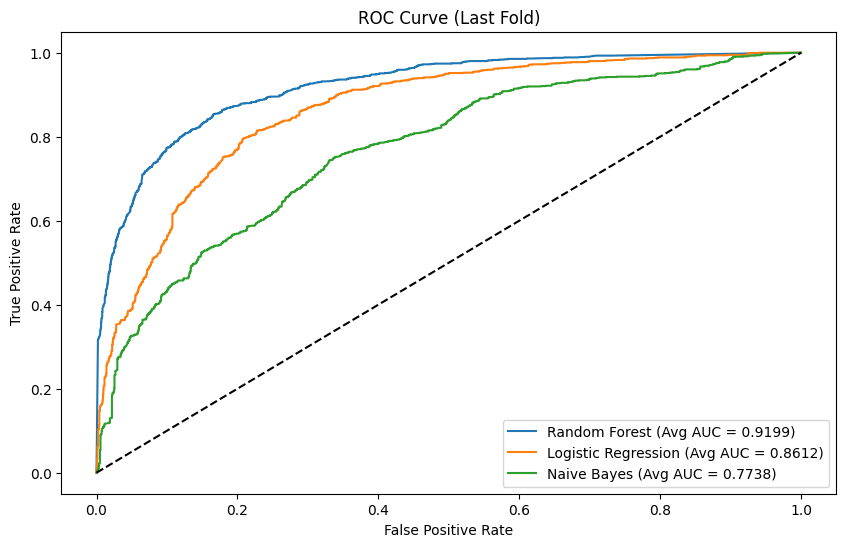

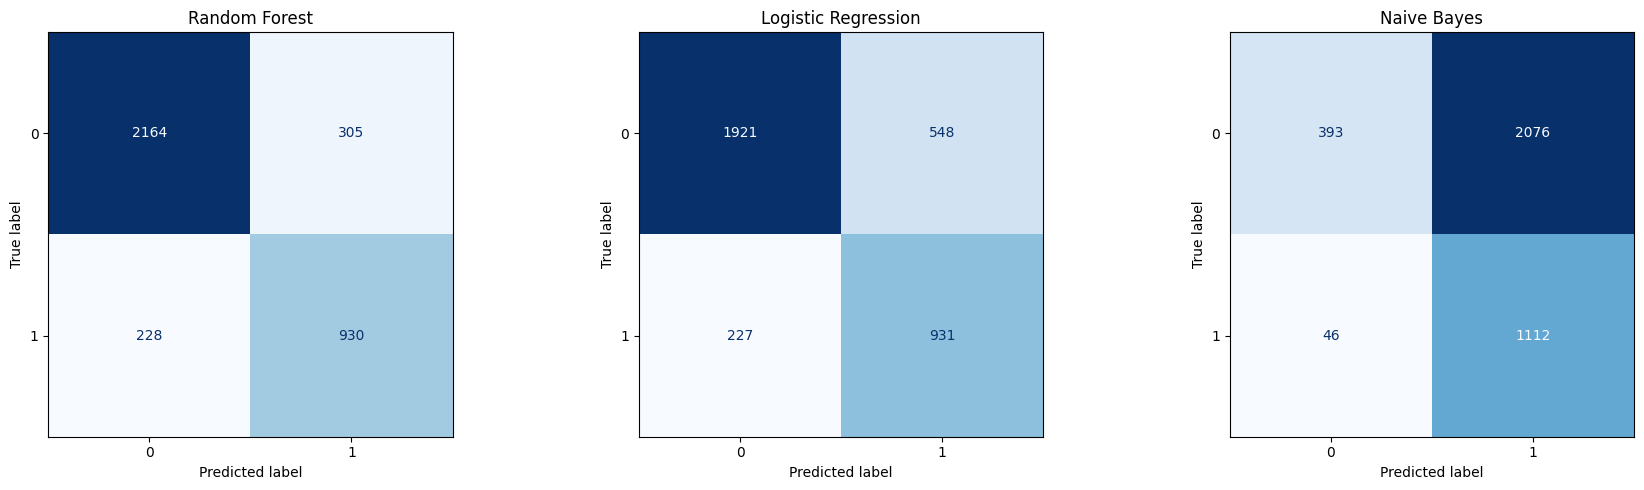

In [ ]:
# Store results
results = {}
roc_curves = {}
final_plot_data = {}

# KONFIGURASI STANDARD K-FOLD
k_fold = KFold(n_splits=10, shuffle=True, random_state=42)

for model_name, base_model in models.items():
    accuracies = []
    sensitivities = []
    specificities = []
    aucs = []
    train_accuracies = []
    test_accuracies = []

    print(f"Processing: {model_name}...")

    # Loop K-Fold
    for i, (train_idx, test_idx) in enumerate(k_fold.split(x_encode, y)):

        # 1. Split Data berdasarkan Index K-Fold
        # Menggunakan .iloc untuk slicing berdasarkan index integer
        X_train, X_test = x_encode.iloc[train_idx], x_encode.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # 2. Scaling (Fit di Train, Transform di Test)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # 3. SMOTE (Hanya pada data Train yang sudah di-scale)
        smote = SMOTE(random_state=42)
        X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

        # 4. GRID SEARCH TUNING
        if model_name in param_grids:
            grid_search = GridSearchCV(
                estimator=base_model,
                param_grid=param_grids[model_name],
                cv=5,
                scoring='accuracy',
                n_jobs=-1
            )
            grid_search.fit(X_train_smote, y_train_smote)
            model = grid_search.best_estimator_

        else:
            # Jika tidak ada di grid, pakai model default
            model = base_model
            model.fit(X_train_smote, y_train_smote)

        # Predict (Gunakan X_test_scaled)
        y_train_pred = model.predict(X_train_smote)
        y_test_pred = model.predict(X_test_scaled)

        # Predict probabilities for AUC if available
        y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None

        # Metrics calculation
        accuracy = accuracy_score(y_test, y_test_pred)
        sensitivity = recall_score(y_test, y_test_pred)
        tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        auc_score = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

        # Train/Test accuracy
        train_accuracy = accuracy_score(y_train_smote, y_train_pred)
        test_accuracy = accuracy_score(y_test, y_test_pred)

        # Store fold results
        accuracies.append(accuracy)
        sensitivities.append(sensitivity)
        specificities.append(specificity)
        aucs.append(auc_score)
        train_accuracies.append(train_accuracy)
        test_accuracies.append(test_accuracy)

        # Simpan data iterasi akhir (Fold ke-10 / Index 9)
        if i == 9:
            final_plot_data[model_name] = {
                'y_test': y_test,
                'y_pred': y_test_pred,
                'y_proba': y_proba
            }

    # Aggregate metrics
    results[model_name] = {
        'Accuracy': np.mean(accuracies),
        'Sensitivity (Recall)': np.mean(sensitivities),
        'Specificity': np.mean(specificities),
        'AUC': np.mean(aucs),
        'Train Accuracy': np.mean(train_accuracies),
        'Test Accuracy': np.mean(test_accuracies),
        'Overfitting Gap': np.mean(train_accuracies) - np.mean(test_accuracies)
    }

    # Store ROC curve for the last iteration
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_curves[model_name] = (fpr, tpr, np.mean(aucs))

# Create DataFrame for the results
metrics_df = pd.DataFrame.from_dict(results, orient='index').reset_index()
metrics_df.columns = [
    "Model", "Accuracy", "Sensitivity", "Specificity", "AUC",
    "Train Accuracy", "Test Accuracy", "Overfitting Gap"
]

# Apply styling
styled_metrics_df = metrics_df.style.highlight_max(
    subset=['Accuracy', 'Sensitivity', 'Specificity', 'AUC', 'Train Accuracy', 'Test Accuracy'],
    color='lightgreen'
)

# Display table
print("\nModel Performance Table:")
display(styled_metrics_df)

# 1. Plot ROC Curves
plt.figure(figsize=(10, 6))
for model_name, (fpr, tpr, auc_score) in roc_curves.items():
    plt.plot(fpr, tpr, label=f'{model_name} (Avg AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Last Fold)')
plt.legend()
plt.show()

# 2. Plot Confusion Matrices
fig, axes = plt.subplots(1, len(models), figsize=(18, 5))

if len(models) == 1:
    axes = [axes]

for ax, (model_name, data) in zip(axes, final_plot_data.items()):
    ConfusionMatrixDisplay.from_predictions(
        data['y_test'],
        data['y_pred'],
        ax=ax,
        cmap='Blues',
        colorbar=False
    )
    ax.set_title(f"{model_name}")

plt.tight_layout()
plt.show()

## Best Model : Random Forest

In [ ]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(x_encode, y, test_size=0.2, random_state=42, stratify=y)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Simpan Scaler
with open('scaler_hotel.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# GRID SEARCH (Hyperparameter Tuning)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Inisialisasi base model
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Inisialisasi Grid Search
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Latih Grid Search pada data SMOTE
grid_search.fit(X_train_smote, y_train_smote)

# AMBIL MODEL TERBAIK
best_rf_model = grid_search.best_estimator_

# Simpan Model Terbaik
with open('rf_bestmodel_hotel.pkl', 'wb') as f:
    pickle.dump(best_rf_model, f)

# Evaluasi
y_pred = best_rf_model.predict(X_test_scaled)
y_proba = best_rf_model.predict_proba(X_test_scaled)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy = accuracy_score(y_test, y_pred)
sensitivity = recall_score(y_test, y_pred)
specificity = tn / (tn + fp)
auc_score = roc_auc_score(y_test, y_proba)


print("EVALUATION METRICS")
print(f"Accuracy    : {accuracy:.4f}")
print(f"Sensitivity : {sensitivity:.4f} (Recall)")
print(f"Specificity : {specificity:.4f}")
print(f"AUC Score   : {auc_score:.4f}")

# Download Files
files.download('scaler_hotel.pkl')
files.download('rf_bestmodel_hotel.pkl')

Fitting 5 folds for each of 12 candidates, totalling 60 fits
EVALUATION METRICS
Accuracy    : 0.8565
Sensitivity : 0.8195 (Recall)
Specificity : 0.8745
AUC Score   : 0.9238


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

End of Code.